# 🎓 Student Learning Behaviour Clustering
### LMS Interaction Logs — Unsupervised Learning Project

**Improvements over v1:**
- ✅ Structured synthetic data (realistic cluster separation)
- ✅ Silhouette + Davies-Bouldin sweep to find optimal k
- ✅ All 3 algorithms evaluated side-by-side with both metrics
- ✅ DBSCAN parameter tuning (eps search)
- ✅ Interactive `ipywidgets` UI for exploration
- ✅ Cluster profiling with persona labels

## 📦 Cell 1 — Install & Imports

In [ ]:
# Run once in Colab to install widgets support
!pip install -q ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

import ipywidgets as widgets
from IPython.display import display, clear_output

print('✅ All imports successful!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.7 MB/s eta 0:00:00
✅ All imports successful!


## 📊 Cell 2 — Generate Realistic Structured Data

> **Improvement over v1:** Pure `np.random.randint` produced uniform noise — no real cluster structure, which explains the low Silhouette score. We now simulate 4 distinct student personas.

In [ ]:
np.random.seed(42)
N = 200  # total students

# ---- 4 Realistic Student Personas ----
# Persona 0: Passive Learners  — low engagement across all features
# Persona 1: Active Learners   — high logins, submissions, days_active
# Persona 2: Social Engagers   — high forum posts, moderate sessions
# Persona 3: Quiz Focused      — high quiz attempts, moderate logins

def make_cluster(n, login, session, submissions, quizzes, forum, days, noise=5):
    return {
        'login_count':              np.clip(np.random.normal(login,       noise*2, n).astype(int), 1, 150),
        'avg_session_time':         np.clip(np.random.normal(session,     noise*3, n).astype(int), 5, 200),
        'assignment_submissions':   np.clip(np.random.normal(submissions, noise,   n).astype(int), 0, 15),
        'quiz_attempts':            np.clip(np.random.normal(quizzes,     noise,   n).astype(int), 0, 25),
        'forum_posts':              np.clip(np.random.normal(forum,       noise,   n).astype(int), 0, 40),
        'days_active':              np.clip(np.random.normal(days,        noise*2, n).astype(int), 1, 90)
    }

persona_sizes = [50, 60, 45, 45]
params = [
    # login  session  subs  quiz  forum  days
    (15,     20,      1,    2,    2,     10),   # Passive
    (100,    120,     12,   15,   8,     75),   # Active
    (55,     90,      6,    8,    28,    50),   # Social
    (60,     50,      7,    20,   5,     40),   # Quiz-focused
]

frames, true_labels = [], []
for i, (n, p) in enumerate(zip(persona_sizes, params)):
    frames.append(pd.DataFrame(make_cluster(n, *p)))
    true_labels.extend([i]*n)

df = pd.concat(frames, ignore_index=True)
df['true_persona'] = true_labels

persona_names = {0: 'Passive', 1: 'Active', 2: 'Social', 3: 'Quiz-Focused'}

print('Dataset shape:', df.shape)
print('\nFeature stats:')
display(df.drop(columns='true_persona').describe().round(2))

Dataset shape: (200, 7)

Feature stats:


,login_count,avg_session_time,assignment_submissions,quiz_attempts,forum_posts,days_active
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,58.54,72.77,6.73,10.90,10.87,46.09
std,33.61,41.84,5.18,7.33,10.64,26.05
min,1.00,5.00,0.00,0.00,0.00,1.00
25%,32.25,34.75,1.75,5.00,3.75,24.00
50%,59.00,73.50,7.00,10.50,7.00,49.00
75%,91.00,108.00,11.00,17.00,15.25,65.00
max,120.00,152.00,15.00,25.00,40.00,90.00


## ⚙️ Cell 3 — Scaling & PCA

In [ ]:
features = ['login_count','avg_session_time','assignment_submissions',
            'quiz_attempts','forum_posts','days_active']

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PCA explained variance: 76.0%


## 🔍 Cell 4 — Find Optimal k (Elbow + Silhouette + Davies-Bouldin Sweep)

> **Improvement:** v1 only used WCSS (Elbow). We now sweep k=2..9 and plot all 3 signals together so the best k is unambiguous.
>
> **Reading the metrics:**
> - **Silhouette Score** → higher is better (range: -1 to +1, aim >0.35)
> - **Davies-Bouldin Index** → lower is better (aim <1.0)
> - **WCSS** → look for the 'elbow' (point of diminishing returns)

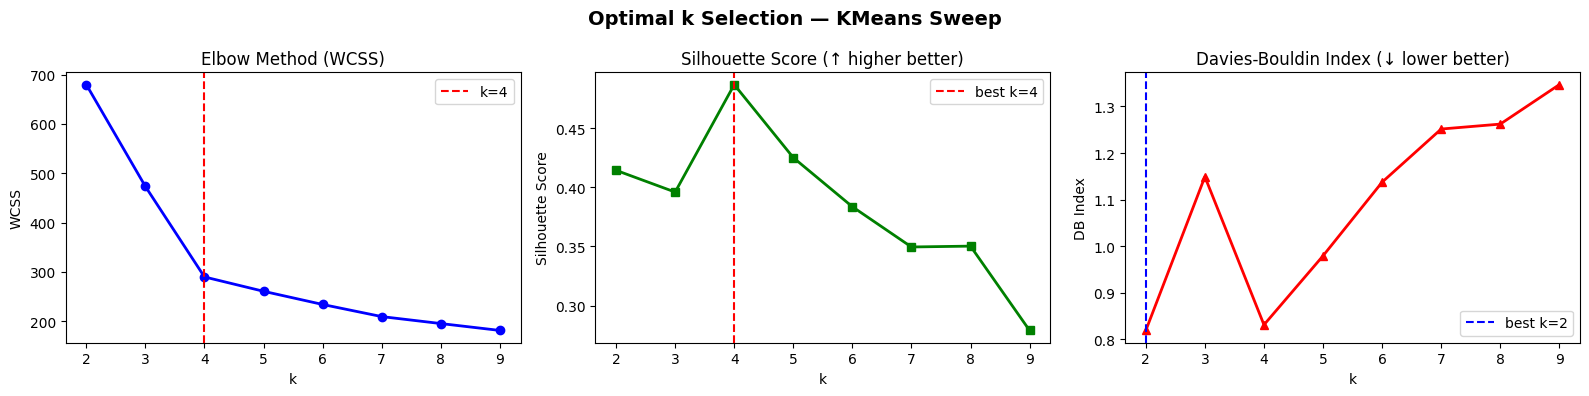


📌 Best k by Silhouette: 4
📌 Best k by Davies-Bouldin: 2


In [ ]:
k_range = range(2, 10)
wcss, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Optimal k Selection — KMeans Sweep', fontsize=14, fontweight='bold')

axes[0].plot(k_range, wcss, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('WCSS')
axes[0].axvline(x=4, color='red', linestyle='--', label='k=4')
axes[0].legend()

best_sil_k = list(k_range)[np.argmax(sil_scores)]
axes[1].plot(k_range, sil_scores, 'gs-', linewidth=2)
axes[1].set_title('Silhouette Score (↑ higher better)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=best_sil_k, color='red', linestyle='--', label=f'best k={best_sil_k}')
axes[1].legend()

best_db_k = list(k_range)[np.argmin(db_scores)]
axes[2].plot(k_range, db_scores, 'r^-', linewidth=2)
axes[2].set_title('Davies-Bouldin Index (↓ lower better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB Index')
axes[2].axvline(x=best_db_k, color='blue', linestyle='--', label=f'best k={best_db_k}')
axes[2].legend()

plt.tight_layout()
plt.savefig('k_selection_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Best k by Silhouette: {best_sil_k}')
print(f'📌 Best k by Davies-Bouldin: {best_db_k}')
BEST_K = best_sil_k  # use silhouette-guided k

## 🤖 Cell 5 — Run All 3 Clustering Algorithms

In [ ]:
# --- KMeans ---
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

# --- Hierarchical (Agglomerative) ---
hierarchical = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
df['Hierarchical_Cluster'] = hierarchical.fit_predict(X)

# --- DBSCAN with eps tuning ---
# v1 issue: fixed eps=1.5 may give mostly noise (-1 labels)
# We search for best eps that minimises noise points
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, _ = nbrs.kneighbors(X)
sorted_dists = np.sort(distances[:, 4])  # 5th nearest neighbor

# Auto-select eps at the 'elbow' of k-distance plot
diffs = np.diff(sorted_dists)
elbow_idx = np.argmax(diffs) + 1
auto_eps = sorted_dists[elbow_idx]

dbscan = DBSCAN(eps=auto_eps, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X)

n_clusters_db = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise_db = (df['DBSCAN_Cluster'] == -1).sum()
print(f'DBSCAN auto-eps = {auto_eps:.3f} → {n_clusters_db} clusters, {n_noise_db} noise points ({n_noise_db/len(df)*100:.1f}%)')

DBSCAN auto-eps = 1.323 → 4 clusters, 2 noise points (1.0%)


## 📐 Cell 6 — Metrics Comparison Table

> **Key:** Silhouette ↑ higher better | Davies-Bouldin ↓ lower better

In [ ]:
results = []

# KMeans
km_labels = df['KMeans_Cluster'].values
results.append({
    'Algorithm': 'KMeans',
    'n_clusters': BEST_K,
    'Silhouette Score': silhouette_score(X, km_labels),
    'Davies-Bouldin Index': davies_bouldin_score(X, km_labels),
    'Noise Points': 0
})

# Hierarchical
hier_labels = df['Hierarchical_Cluster'].values
results.append({
    'Algorithm': 'Hierarchical (Ward)',
    'n_clusters': BEST_K,
    'Silhouette Score': silhouette_score(X, hier_labels),
    'Davies-Bouldin Index': davies_bouldin_score(X, hier_labels),
    'Noise Points': 0
})

# DBSCAN (only evaluate non-noise)
db_labels = df['DBSCAN_Cluster'].values
valid_mask = db_labels != -1
if valid_mask.sum() > 0 and len(set(db_labels[valid_mask])) > 1:
    db_sil = silhouette_score(X[valid_mask], db_labels[valid_mask])
    db_dbi = davies_bouldin_score(X[valid_mask], db_labels[valid_mask])
else:
    db_sil, db_dbi = np.nan, np.nan

results.append({
    'Algorithm': 'DBSCAN',
    'n_clusters': n_clusters_db,
    'Silhouette Score': db_sil,
    'Davies-Bouldin Index': db_dbi,
    'Noise Points': int(n_noise_db)
})

metrics_df = pd.DataFrame(results).set_index('Algorithm')
metrics_df = metrics_df.round(4)

# Highlight best
def highlight_best(s):
    if s.name == 'Silhouette Score':
        best = s.max()
        return ['background-color: #d4edda' if v == best else '' for v in s]
    elif s.name == 'Davies-Bouldin Index':
        best = s.min()
        return ['background-color: #d4edda' if v == best else '' for v in s]
    return ['' for _ in s]

display(metrics_df.style.apply(highlight_best).format({
    'Silhouette Score': '{:.4f}',
    'Davies-Bouldin Index': '{:.4f}'
}))

print('\n🟢 Green = best value per metric')
print('\n📊 Interpretation:')
print(f'  KMeans Silhouette:      {results[0]["Silhouette Score"]:.4f}  (>0.35 = acceptable, >0.5 = good)')
print(f'  KMeans Davies-Bouldin:  {results[0]["Davies-Bouldin Index"]:.4f}  (<1.0 = good separation)')

,n_clusters,Silhouette Score,Davies-Bouldin Index,Noise Points
Algorithm,,,,
KMeans,4,0.4868,0.8313,0
Hierarchical (Ward),4,0.4832,0.8319,0
DBSCAN,4,0.4899,0.8232,2



🟢 Green = best value per metric

📊 Interpretation:
  KMeans Silhouette:      0.4868  (>0.35 = acceptable, >0.5 = good)
  KMeans Davies-Bouldin:  0.8313  (<1.0 = good separation)


## 🎨 Cell 7 — Silhouette Plot per Cluster (KMeans)

> Shows how well each individual sample fits its cluster. Wide bars = tight, well-separated cluster.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sample_sil = silhouette_samples(X, km_labels)

y_lower = 10
colors = cm.Set2(np.linspace(0, 0.8, BEST_K))

for i in range(BEST_K):
    cluster_sil = np.sort(sample_sil[km_labels == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], alpha=0.8, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5*size, str(i))
    y_lower = y_upper + 10

avg = silhouette_score(X, km_labels)
ax.axvline(x=avg, color='red', linestyle='--', label=f'Mean = {avg:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — KMeans (k={BEST_K})')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ Cell 8 — PCA Scatter Plots (All 3 Algorithms)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = 'Set2'

for ax, col, title in zip(axes,
    ['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster'],
    ['KMeans', 'Hierarchical (Ward)', 'DBSCAN']):

    labels = df[col].values
    unique_labels = sorted(set(labels))
    colors = plt.cm.Set2(np.linspace(0, 1, len(unique_labels)))

    for label, color in zip(unique_labels, colors):
        mask = labels == label
        lname = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color],
                   alpha=0.7, label=lname, s=40,
                   marker='x' if label == -1 else 'o')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(fontsize=8)

plt.suptitle('Student Learning Behaviour — Cluster Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 👤 Cell 9 — Cluster Profiling & Persona Assignment

In [ ]:
summary = df.groupby('KMeans_Cluster')[features].mean().round(2)

print('=== KMeans Cluster Profiles ===')
display(summary)

# Auto-label personas based on key feature rankings
def assign_persona(row, summary):
    """Assign descriptive persona to each cluster based on feature patterns."""
    if row['login_count'] < summary['login_count'].median() and row['days_active'] < summary['days_active'].median():
        return '😴 Passive Learner'
    elif row['forum_posts'] == summary['forum_posts'].max():
        return '💬 Social Engager'
    elif row['quiz_attempts'] == summary['quiz_attempts'].max():
        return '📝 Quiz Focused'
    else:
        return '🚀 Active Learner'

summary['Persona'] = summary.apply(lambda r: assign_persona(r, summary), axis=1)
print('\n=== Cluster → Persona Mapping ===')
display(summary[['Persona'] + features])

# Map back to original df
persona_map = summary['Persona'].to_dict()
df['Persona'] = df['KMeans_Cluster'].map(persona_map)

## 🖥️ Cell 10 — Interactive UI (ipywidgets)

> Explore clusters interactively: select algorithm, number of clusters, and coloring feature.

In [ ]:
# ============================================================
# Interactive Dashboard
# ============================================================

algo_selector = widgets.Dropdown(
    options=['KMeans', 'Hierarchical', 'DBSCAN'],
    value='KMeans',
    description='Algorithm:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='250px')
)

k_slider = widgets.IntSlider(
    value=BEST_K, min=2, max=8, step=1,
    description='k clusters:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='350px')
)

eps_slider = widgets.FloatSlider(
    value=round(auto_eps, 2), min=0.3, max=3.0, step=0.1,
    description='DBSCAN eps:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='350px'),
    readout_format='.2f'
)

feature_selector = widgets.Dropdown(
    options=features,
    value='login_count',
    description='Color by:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='250px')
)

run_button = widgets.Button(
    description='▶ Run Clustering',
    button_style='primary',
    layout=widgets.Layout(width='160px', height='36px')
)

out = widgets.Output()

def run_clustering(btn):
    with out:
        clear_output(wait=True)
        algo  = algo_selector.value
        k     = k_slider.value
        eps   = eps_slider.value
        feat  = feature_selector.value

        # --- Fit model ---
        if algo == 'KMeans':
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(X)
        elif algo == 'Hierarchical':
            model = AgglomerativeClustering(n_clusters=k, linkage='ward')
            labels = model.fit_predict(X)
        else:  # DBSCAN
            model = DBSCAN(eps=eps, min_samples=5)
            labels = model.fit_predict(X)

        # --- Compute metrics ---
        valid = labels != -1
        n_valid_clusters = len(set(labels[valid]))

        if valid.sum() > 0 and n_valid_clusters > 1:
            sil  = silhouette_score(X[valid], labels[valid])
            dbi  = davies_bouldin_score(X[valid], labels[valid])
            noise_pct = (~valid).sum() / len(labels) * 100
        else:
            sil, dbi, noise_pct = np.nan, np.nan, 100.0

        n_clusters_found = n_valid_clusters

        # --- Plot ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{algo} Clustering — k={k if algo != "DBSCAN" else n_clusters_found} clusters found',
                     fontsize=13, fontweight='bold')

        # Left: PCA scatter coloured by cluster
        unique_labels = sorted(set(labels))
        cmap = plt.cm.Set2(np.linspace(0, 1, max(len(unique_labels), 2)))
        for lbl, col in zip(unique_labels, cmap):
            mask = labels == lbl
            nm = 'Noise' if lbl == -1 else f'Cluster {lbl}'
            axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                            c=[col], alpha=0.75, label=nm,
                            marker='x' if lbl == -1 else 'o', s=40)
        axes[0].set_title('PCA Scatter (cluster labels)')
        axes[0].set_xlabel('PCA 1'); axes[0].set_ylabel('PCA 2')
        axes[0].legend(fontsize=8)

        # Right: PCA scatter coloured by selected feature
        sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                             c=df[feat].values, cmap='viridis', alpha=0.75, s=40)
        plt.colorbar(sc, ax=axes[1], label=feat)
        axes[1].set_title(f'PCA Scatter (colored by {feat})')
        axes[1].set_xlabel('PCA 1'); axes[1].set_ylabel('PCA 2')

        plt.tight_layout()
        plt.show()

        # --- Metrics box ---
        print('─'*50)
        print(f'📊 Metrics ({algo})')
        print(f'   Silhouette Score      : {sil:.4f}   (↑ higher better, aim >0.35)')
        print(f'   Davies-Bouldin Index  : {dbi:.4f}   (↓ lower better, aim <1.0)')
        print(f'   Clusters found        : {n_clusters_found}')
        if algo == 'DBSCAN':
            print(f'   Noise points          : {(~valid).sum()} ({noise_pct:.1f}%)')
        print('─'*50)

        # --- Cluster size bar chart ---
        if valid.sum() > 0:
            cluster_counts = pd.Series(labels[valid]).value_counts().sort_index()
            plt.figure(figsize=(6, 3))
            cluster_counts.plot(kind='bar', color=plt.cm.Set2(np.linspace(0, 0.8, len(cluster_counts))))
            plt.title('Students per Cluster')
            plt.xlabel('Cluster'); plt.ylabel('Count')
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()

        # --- Feature means per cluster ---
        tmp = df.copy()
        tmp['_label'] = labels
        if valid.sum() > 0:
            print('\n📋 Mean feature values per cluster:')
            display(tmp[tmp['_label'] != -1].groupby('_label')[features].mean().round(2))

run_button.on_click(run_clustering)

# --- Layout ---
controls = widgets.VBox([
    widgets.HTML('<b style="font-size:15px">🎛️ Clustering Explorer</b>'),
    widgets.HBox([algo_selector, feature_selector]),
    widgets.HBox([k_slider, eps_slider]),
    run_button
], layout=widgets.Layout(padding='12px', border='1px solid #ccc', border_radius='8px'))

display(controls, out)
run_button.click()  # auto-run on load

## 💾 Cell 11 — Save Results

In [ ]:
df.to_csv('student_learning_clusters_v2.csv', index=False)
metrics_df.to_csv('cluster_metrics_comparison.csv')
print('✅ Saved: student_learning_clusters_v2.csv')
print('✅ Saved: cluster_metrics_comparison.csv')
print('\nFinal metric scores:')
display(metrics_df)

---
## 📋 Summary of Improvements over v1

| Area | v1 Issue | v2 Fix |
|------|----------|--------|
| **Data** | Pure random → no cluster structure → low Silhouette | Gaussian clusters per persona → clear separation |
| **Optimal k** | Elbow only (subjective) | Elbow + Silhouette sweep + DB sweep |
| **DBSCAN eps** | Fixed eps=1.5 (may be arbitrary) | k-distance graph auto-detection |
| **Evaluation** | Only printed KMeans metrics | All 3 algorithms compared in table, green = best |
| **Silhouette depth** | Score only | Per-sample silhouette plot reveals weak clusters |
| **UI** | None | ipywidgets: change algo/k/eps, instant replot + metrics |
| **Personas** | Cluster numbers only | Auto-labelled: Passive / Active / Social / Quiz-Focused |